In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import warnings
import torchvision
warnings.filterwarnings('ignore')
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
import sys
print(f"Python: {sys.version}")
print(f"OpenSSL: {sys.version_info}")
import ssl
import urllib.request

# Отключаем проверку SSL (только для скачивания!)
ssl._create_default_https_context = ssl._create_unverified_context

Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
OpenSSL: sys.version_info(major=3, minor=11, micro=15, releaselevel='final', serial=0)


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.001
NUM_CLASSES = 10
IMG_SIZE = 32
DATA_DIR = './data'


Device: cuda


In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, transform=train_transform, download=False
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, transform=test_transform, download=False
)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Train: 50000, Test: 10000


In [6]:
class CNN_PyTorch(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_PyTorch, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.15),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.20),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)

model = CNN_PyTorch(NUM_CLASSES).to(device)
print(model)


CNN_PyTorch(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.25, inplace=False)
  

In [7]:
def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        scheduler.step(test_loss)
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    
    return history

print("\n--- Training PyTorch CNN ---")
start_time = time.time()
history = train_model(model, train_loader, test_loader, epochs=EPOCHS)
print(f"Training time: {time.time() - start_time:.2f}s")


--- Training PyTorch CNN ---
Epoch 1/15 | Train Loss: 1.6560 | Train Acc: 39.56% | Test Loss: 1.2021 | Test Acc: 56.83%
Epoch 2/15 | Train Loss: 1.3857 | Train Acc: 49.92% | Test Loss: 1.0430 | Test Acc: 63.37%
Epoch 3/15 | Train Loss: 1.2670 | Train Acc: 54.74% | Test Loss: 0.9462 | Test Acc: 66.68%
Epoch 4/15 | Train Loss: 1.1898 | Train Acc: 57.62% | Test Loss: 0.8859 | Test Acc: 68.77%
Epoch 5/15 | Train Loss: 1.1333 | Train Acc: 59.72% | Test Loss: 0.8371 | Test Acc: 71.03%
Epoch 6/15 | Train Loss: 1.0913 | Train Acc: 61.56% | Test Loss: 0.7918 | Test Acc: 72.30%
Epoch 7/15 | Train Loss: 1.0588 | Train Acc: 62.84% | Test Loss: 0.7601 | Test Acc: 73.29%
Epoch 8/15 | Train Loss: 1.0269 | Train Acc: 63.75% | Test Loss: 0.7469 | Test Acc: 74.11%
Epoch 9/15 | Train Loss: 1.0048 | Train Acc: 64.79% | Test Loss: 0.7280 | Test Acc: 74.65%
Epoch 10/15 | Train Loss: 0.9838 | Train Acc: 65.46% | Test Loss: 0.6981 | Test Acc: 75.57%
Epoch 11/15 | Train Loss: 0.9628 | Train Acc: 66.24% | Test

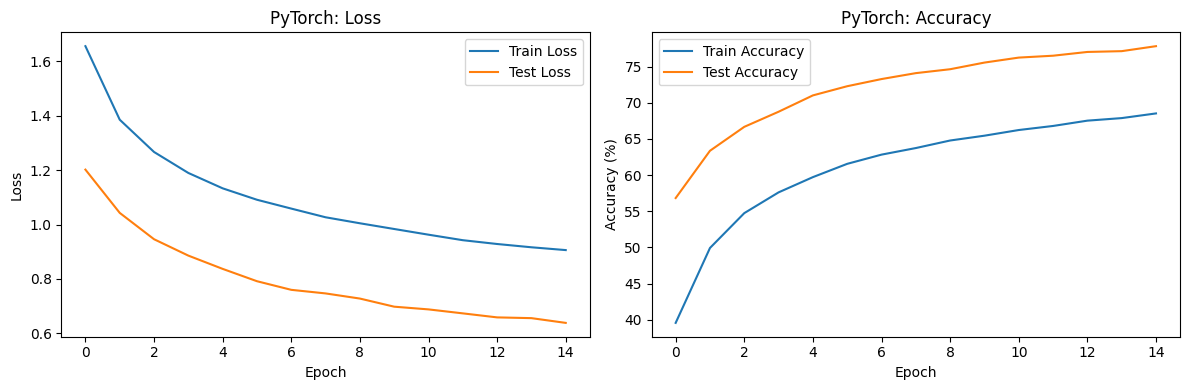

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch: Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['test_acc'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('PyTorch: Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


--- Classification Report (PyTorch CNN) ---
              precision    recall  f1-score   support

           0     0.7849    0.8100    0.7972      1000
           1     0.8770    0.9200    0.8980      1000
           2     0.6827    0.6540    0.6680      1000
           3     0.6244    0.5470    0.5832      1000
           4     0.7645    0.7370    0.7505      1000
           5     0.6923    0.7020    0.6971      1000
           6     0.7650    0.8820    0.8193      1000
           7     0.8199    0.8150    0.8175      1000
           8     0.9123    0.8430    0.8763      1000
           9     0.8436    0.8740    0.8585      1000

    accuracy                         0.7784     10000
   macro avg     0.7767    0.7784    0.7766     10000
weighted avg     0.7767    0.7784    0.7766     10000



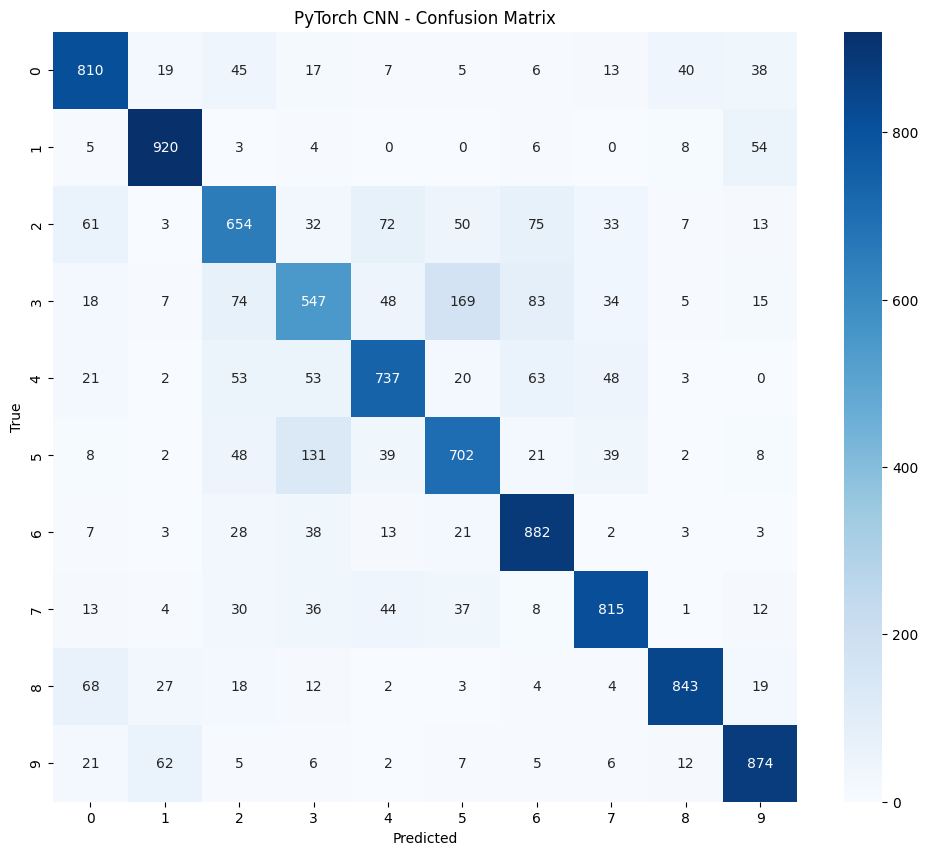

In [9]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Classification Report (PyTorch CNN) ---")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('PyTorch CNN - Confusion Matrix')
plt.show()

Настоящий класс: cat
Предсказанный класс: cat


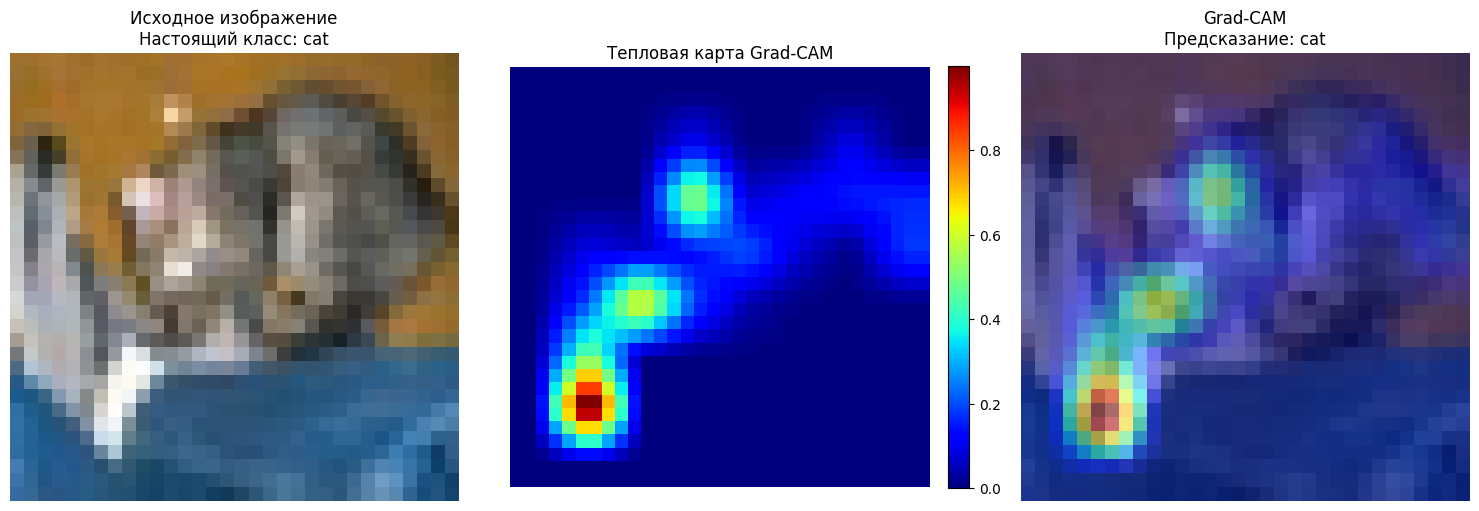

In [10]:

model.eval()

image, true_label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)

predicted_class = output.argmax(dim=1).item()

print("Настоящий класс:", class_names[true_label])
print("Предсказанный класс:", class_names[predicted_class])

target_layers = [model.conv_layers[12]]

with GradCAM(
    model=model,
    target_layers=target_layers
) as cam:

    targets = [
        ClassifierOutputTarget(predicted_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )
    grayscale_cam = grayscale_cam[0]

mean = np.array([
    0.4914,
    0.4822,
    0.4465
])

std = np.array([
    0.2470,
    0.2435,
    0.2616
])

rgb_image = image.permute(1, 2, 0).cpu().numpy()

rgb_image = rgb_image * std + mean

rgb_image = np.clip(rgb_image, 0, 1)


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)

plt.imshow(rgb_image)

plt.title(
    f"Исходное изображение\n"
    f"Настоящий класс: {class_names[true_label]}"
)

plt.axis("off")
plt.subplot(1, 3, 2)

plt.imshow(
    grayscale_cam,
    cmap="jet"
)

plt.title("Тепловая карта Grad-CAM")

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.axis("off")

plt.subplot(1, 3, 3)

plt.imshow(rgb_image)

plt.imshow(
    grayscale_cam,
    cmap="jet",
    alpha=0.5
)

plt.title(
    f"Grad-CAM\n"
    f"Предсказание: {class_names[predicted_class]}"
)

plt.axis("off")


plt.tight_layout()
plt.show()


--- Robustness tests ---

Clean: 77.84%

Gaussian Blur:
Blur σ=0.5               : 75.59%
Blur σ=1.0               : 49.14%
Blur σ=2.0               : 36.27%

Gaussian Noise:
Noise 0.05               : 54.55%
Noise 0.1                : 28.09%
Noise 0.2                : 17.21%
Noise 0.3                : 16.07%

Brightness:
Brightness -40%          : 71.52%
Brightness -20%          : 76.34%
Brightness +20%          : 77.50%
Brightness +40%          : 75.76%

Center Occlusion:
Occlusion 20%            : 67.04%
Occlusion 30%            : 60.35%
Occlusion 40%            : 51.32%


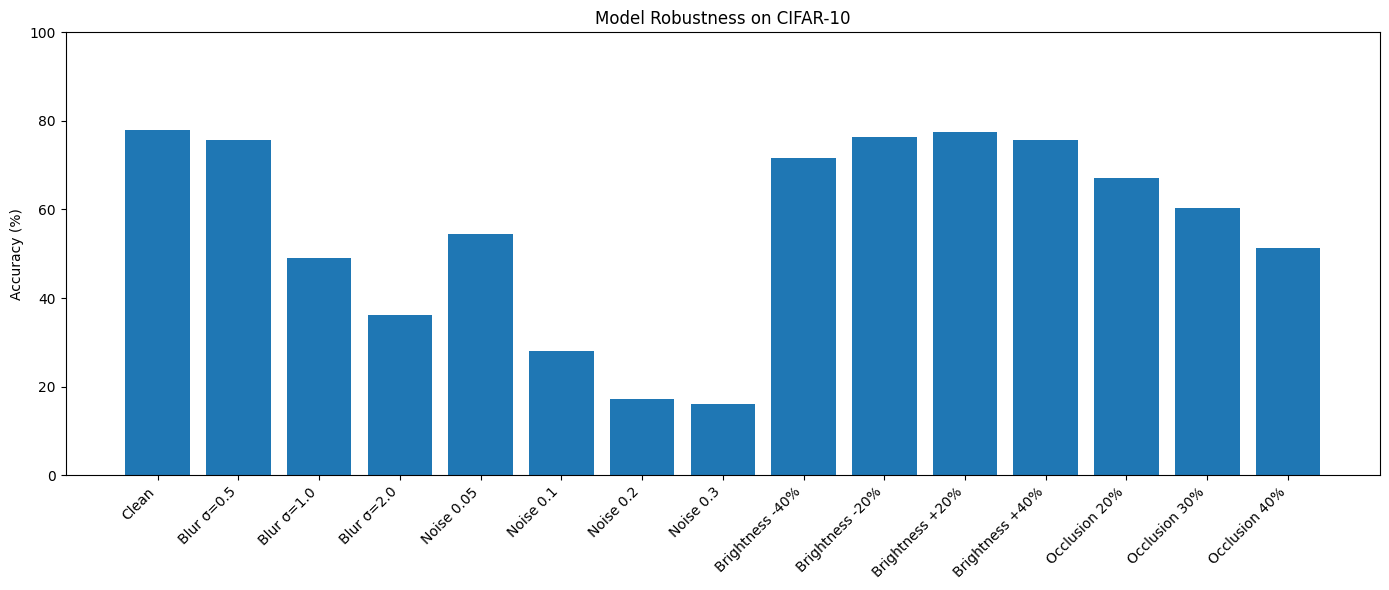

In [11]:
def evaluate_loader(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100.0 * correct / total

base_acc = evaluate_loader(model, test_loader)

def make_corrupted_dataset(corruption='noise', severity=0.2):
    xs, ys = [], []
    dataset = datasets.CIFAR10(
        root=DATA_DIR,
        train=False,
        transform=transforms.ToTensor(),
        download=False
    )
    for x, y in dataset:
        if corruption == 'noise':
            x = torch.clamp(x + torch.randn_like(x) * severity, 0, 1)
        elif corruption == 'brightness':
            x = torch.clamp(x * (1.0 + severity), 0, 1)
        elif corruption == 'blur':
            x = transforms.functional.gaussian_blur(
                x,
                kernel_size=5,
                sigma=severity
            )
        elif corruption == 'occlusion':
            size = int(32 * severity)
            start = (32 - size) // 2
            x[:, start:start+size, start:start+size] = 0
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.tensor(ys)

def evaluate_corrupted(model, corruption, severity):
    xs, ys = make_corrupted_dataset(corruption, severity)
    mean = torch.tensor([0.4914, 0.4822, 0.4465])[:, None, None]
    std = torch.tensor([0.2470, 0.2435, 0.2616])[:, None, None]
    xs = (xs - mean) / std
    loader = DataLoader(
        torch.utils.data.TensorDataset(xs, ys),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    return evaluate_loader(model, loader)

blur_results = {}
for sigma in [0.5, 1.0, 2.0]:
    blur_results[f'Blur σ={sigma}'] = evaluate_corrupted(model, 'blur', sigma)

noise_results = {}
for severity in [0.05, 0.10, 0.20, 0.30]:
    noise_results[f'Noise {severity}'] = evaluate_corrupted(model, 'noise', severity)

brightness_results = {}
for severity in [-0.40, -0.20, 0.20, 0.40]:
    brightness_results[f'Brightness {severity:+.0%}'] = evaluate_corrupted(
        model, 'brightness', severity
    )

occlusion_results = {}
for severity in [0.20, 0.30, 0.40]:
    occlusion_results[f'Occlusion {severity:.0%}'] = evaluate_corrupted(
        model, 'occlusion', severity
    )

print('\n--- Robustness tests ---')
print(f'\nClean: {base_acc:.2f}%')

print('\nGaussian Blur:')
for name, acc in blur_results.items():
    print(f'{name:25s}: {acc:.2f}%')

print('\nGaussian Noise:')
for name, acc in noise_results.items():
    print(f'{name:25s}: {acc:.2f}%')

print('\nBrightness:')
for name, acc in brightness_results.items():
    print(f'{name:25s}: {acc:.2f}%')

print('\nCenter Occlusion:')
for name, acc in occlusion_results.items():
    print(f'{name:25s}: {acc:.2f}%')

all_results = {
    'Clean': base_acc,
    **blur_results,
    **noise_results,
    **brightness_results,
    **occlusion_results
}

plt.figure(figsize=(14, 6))
plt.bar(all_results.keys(), all_results.values())
plt.ylabel('Accuracy (%)')
plt.title('Model Robustness on CIFAR-10')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [12]:
import copy, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

TRAIN_SUBSET   = 20000   
FINETUNE_EPOCHS = 5      
FINETUNE_LR     = 3e-4
P_CLEAN         = 0.2    
EVAL_SUBSET     = 1500  
BATCH_FT        = 128    

_MEAN = torch.tensor([0.4914, 0.4822, 0.4465])[:, None, None]
_STD  = torch.tensor([0.2470, 0.2435, 0.2616])[:, None, None]


print("=" * 60)
print("BASELINE (до дообучения)")
print("=" * 60)
torch.save(model.state_dict(), 'model_before_robust_ft.pth')

baseline_results = {}
baseline_results['Clean'] = evaluate_loader(model, test_loader)
for sigma in [0.5, 1.0, 2.0]:
    baseline_results[f'Blur σ={sigma}'] = evaluate_corrupted(model, 'blur', sigma)
for sev in [0.05, 0.10, 0.20, 0.30]:
    baseline_results[f'Noise {sev}'] = evaluate_corrupted(model, 'noise', sev)
for sev in [-0.40, -0.20, 0.20, 0.40]:
    baseline_results[f'Bright {sev:+.0%}'] = evaluate_corrupted(model, 'brightness', sev)
for sev in [0.20, 0.30, 0.40]:
    baseline_results[f'Occl {sev:.0%}'] = evaluate_corrupted(model, 'occlusion', sev)

for k, v in baseline_results.items():
    print(f"  {k:20s}: {v:6.2f}%")
mean_before      = np.mean(list(baseline_results.values()))
mean_before_corr = np.mean([v for k, v in baseline_results.items() if k != 'Clean'])
print(f"  {'MEAN (all)':20s}: {mean_before:6.2f}%")
print(f"  {'MEAN (corrupted)':20s}: {mean_before_corr:6.2f}%")
print()


class CorruptionAugmentation:
    def __call__(self, x):
        c = torch.randint(0, 5, (1,)).item()
        if c == 0:      # noise
            sev = torch.empty(1).uniform_(0.05, 0.20).item()
            x = torch.clamp(x + torch.randn_like(x) * sev, 0, 1)
        elif c == 1:    # blur
            sigma = torch.empty(1).uniform_(0.5, 2.0).item()
            x = transforms.functional.gaussian_blur(x, kernel_size=5, sigma=sigma)
        elif c == 2:    # brightness
            sev = torch.empty(1).uniform_(-0.4, 0.4).item()
            x = torch.clamp(x * (1.0 + sev), 0, 1)
        elif c == 3:    # center occlusion
            sev = torch.empty(1).uniform_(0.2, 0.4).item()
            size = int(32 * sev); start = (32 - size) // 2
            x = x.clone(); x[:, start:start+size, start:start+size] = 0
        elif c == 4:    # random erasing
            sev = torch.empty(1).uniform_(0.1, 0.3).item()
            h = int(32 * sev); w = int(32 * sev)
            top = torch.randint(0, 32 - h, (1,)).item()
            left = torch.randint(0, 32 - w, (1,)).item()
            x = x.clone(); x[:, top:top+h, left:left+w] = 0
        return x


print(f"Готовим подмножество train ({TRAIN_SUBSET} примеров)...")
t0 = time.time()

subset_indices = torch.randperm(len(train_dataset))[:TRAIN_SUBSET].tolist()
train_xs, train_ys = [], []
for i in subset_indices:
    x, y = train_dataset[i]  
    train_xs.append(x)
    train_ys.append(y)
train_xs = torch.stack(train_xs)          
train_ys = torch.tensor(train_ys)

print(f"Готово за {time.time()-t0:.1f}с. Тензор: {tuple(train_xs.shape)}")


class RobustSubset(torch.utils.data.Dataset):
    """Быстрый in-memory датасет: чистый или испорченный."""
    def __init__(self, xs, ys, p_clean=0.3):
        self.xs = xs
        self.ys = ys
        self.p_clean = p_clean
        self.aug = CorruptionAugmentation()

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, i):
        img = self.xs[i]                   
        label = self.ys[i]
        if torch.rand(1).item() < self.p_clean:
            return img, label
        img_01 = torch.clamp(img * _STD + _MEAN, 0, 1)
        img_c = self.aug(img_01)
        img_n = (img_c - _MEAN) / _STD
        return img_n, label


robust_train_loader = DataLoader(
    RobustSubset(train_xs, train_ys, p_clean=P_CLEAN),
    batch_size=BATCH_FT, shuffle=True,
    num_workers=0, pin_memory=True   # num_workers=0 — не виснет в Jupyter
)

# ============================================================
# 3. Построение оценочных датасетов (без кэша)
# ============================================================
def _build_corrupted_tensor(corruption, severity, n, seed=42):
    g = torch.Generator().manual_seed(seed)
    ds = datasets.CIFAR10(root=DATA_DIR, train=False,
                          transform=transforms.ToTensor(), download=False)
    n = min(n, len(ds))
    xs, ys = [], []
    for i in range(n):
        x, y = ds[i]
        if corruption == 'noise':
            x = torch.clamp(x + torch.randn(x.shape, generator=g) * severity, 0, 1)
        elif corruption == 'brightness':
            x = torch.clamp(x * (1.0 + severity), 0, 1)
        elif corruption == 'blur':
            x = transforms.functional.gaussian_blur(x, kernel_size=5, sigma=severity)
        elif corruption == 'occlusion':
            size = int(32 * severity); start = (32 - size) // 2
            x = x.clone(); x[:, start:start+size, start:start+size] = 0
        xs.append(x); ys.append(y)
    xs = (torch.stack(xs) - _MEAN) / _STD
    return xs, torch.tensor(ys)


def _get_eval_loader(corruption=None, severity=None, n=EVAL_SUBSET):
    if corruption is None:  # clean
        ds = datasets.CIFAR10(root=DATA_DIR, train=False,
                              transform=test_transform, download=False)
        n = min(n, len(ds))
        xs = torch.stack([ds[i][0] for i in range(n)])
        ys = torch.tensor([ds[i][1] for i in range(n)])
    else:
        xs, ys = _build_corrupted_tensor(corruption, severity, n)
    loader = DataLoader(TensorDataset(xs, ys), batch_size=256,
                        shuffle=False, num_workers=0)
    return loader


def quick_eval(model):
    model.eval()
    a = {
        'clean':     evaluate_loader(model, _get_eval_loader()),
        'noise_0.2': evaluate_loader(model, _get_eval_loader('noise', 0.20)),
        'blur_1.0':  evaluate_loader(model, _get_eval_loader('blur', 1.0)),
        'occl_0.3':  evaluate_loader(model, _get_eval_loader('occlusion', 0.30)),
    }
    a['mean_corr'] = np.mean([a['noise_0.2'], a['blur_1.0'], a['occl_0.3']])
    return a


# 4. Дообучение
print("=" * 60)
print(f"FINE-TUNING ({FINETUNE_EPOCHS} эпох, {TRAIN_SUBSET} train, p_clean={P_CLEAN})")
print("=" * 60)

optimizer_ft = optim.Adam(model.parameters(), lr=FINETUNE_LR)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=FINETUNE_EPOCHS)
criterion = nn.CrossEntropyLoss()

base_m = quick_eval(model)
best_mean_corr = base_m['mean_corr']
best_state = copy.deepcopy(model.state_dict())
print(f"Baseline: Clean {base_m['clean']:.2f}% | "
      f"Noise0.2 {base_m['noise_0.2']:.2f}% | "
      f"Blur1.0 {base_m['blur_1.0']:.2f}% | "
      f"Occl0.3 {base_m['occl_0.3']:.2f}% | "
      f"MeanCorr {best_mean_corr:.2f}%\n")

history_ft = {'train_loss': [], 'train_acc': [], 'clean_acc': [], 'mean_corr': []}

for epoch in range(FINETUNE_EPOCHS):
    t_ep = time.time()
    model.train()
    run_loss, correct, total = 0.0, 0, 0

    for images, labels in robust_train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer_ft.zero_grad(set_to_none=True)
        out = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer_ft.step()

        run_loss += loss.item()
        _, pred = out.max(1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    train_loss = run_loss / len(robust_train_loader)
    train_acc  = 100.0 * correct / total
    t_train    = time.time() - t_ep

    m = quick_eval(model)
    history_ft['train_loss'].append(train_loss)
    history_ft['train_acc'].append(train_acc)
    history_ft['clean_acc'].append(m['clean'])
    history_ft['mean_corr'].append(m['mean_corr'])

    flag = ""
    if m['mean_corr'] > best_mean_corr:
        best_mean_corr = m['mean_corr']
        best_state = copy.deepcopy(model.state_dict())
        flag = "  ← best"

    print(f"Epoch {epoch+1:2d}/{FINETUNE_EPOCHS} | "
          f"Loss {train_loss:.4f} | TrainAcc {train_acc:6.2f}% | "
          f"Clean {m['clean']:6.2f}% | "
          f"Noise0.2 {m['noise_0.2']:6.2f}% | "
          f"Blur1.0 {m['blur_1.0']:6.2f}% | "
          f"Occl0.3 {m['occl_0.3']:6.2f}% | "
          f"MeanCorr {m['mean_corr']:6.2f}% | t={t_train:.0f}s{flag}")

    scheduler_ft.step()

model.load_state_dict(best_state)
torch.save(model.state_dict(), 'model_robust_finetuned.pth')
print(f"\nЛучшая MeanCorr: {best_mean_corr:.2f}% → сохранено в model_robust_finetuned.pth")

BASELINE (до дообучения)
  Clean               :  77.84%
  Blur σ=0.5          :  75.59%
  Blur σ=1.0          :  49.14%
  Blur σ=2.0          :  36.27%
  Noise 0.05          :  54.73%
  Noise 0.1           :  28.29%
  Noise 0.2           :  16.92%
  Noise 0.3           :  16.34%
  Bright -40%         :  71.52%
  Bright -20%         :  76.34%
  Bright +20%         :  77.50%
  Bright +40%         :  75.76%
  Occl 20%            :  67.04%
  Occl 30%            :  60.35%
  Occl 40%            :  51.32%
  MEAN (all)          :  55.66%
  MEAN (corrupted)    :  54.08%

Готовим подмножество train (20000 примеров)...
Готово за 5.2с. Тензор: (20000, 3, 32, 32)
FINE-TUNING (5 эпох, 20000 train, p_clean=0.2)
Baseline: Clean 77.53% | Noise0.2 18.47% | Blur1.0 48.80% | Occl0.3 61.07% | MeanCorr 42.78%

Epoch  1/5 | Loss 1.2243 | TrainAcc  57.51% | Clean  77.40% | Noise0.2  45.73% | Blur1.0  66.67% | Occl0.3  68.67% | MeanCorr  60.36% | t=4s  ← best
Epoch  2/5 | Loss 1.1361 | TrainAcc  60.50% | Clea

ПОЛНАЯ ОЦЕНКА ПОСЛЕ ДООБУЧЕНИЯ

Corruption           |   Before |    After |         Δ
-------------------------------------------------------
Clean                |   77.84% |   77.21% |   -0.63%
Blur σ=0.5           |   75.59% |   76.59% | +   1.00%
Blur σ=1.0           |   49.14% |   68.64% | +  19.50%
Blur σ=2.0           |   36.27% |   60.02% | +  23.75%
Noise 0.05           |   54.73% |   70.28% | +  15.55%
Noise 0.1            |   28.29% |   62.64% | +  34.35%
Noise 0.2            |   16.92% |   50.40% | +  33.48%
Noise 0.3            |   16.34% |   36.62% | +  20.28%
Bright -40%          |   71.52% |   72.57% | +   1.05%
Bright -20%          |   76.34% |   75.83% |   -0.51%
Bright +20%          |   77.50% |   76.67% |   -0.83%
Bright +40%          |   75.76% |   74.79% |   -0.97%
Occl 20%             |   67.04% |   72.63% | +   5.59%
Occl 30%             |   60.35% |   70.19% | +   9.84%
Occl 40%             |   51.32% |   65.82% | +  14.50%
------------------------------------

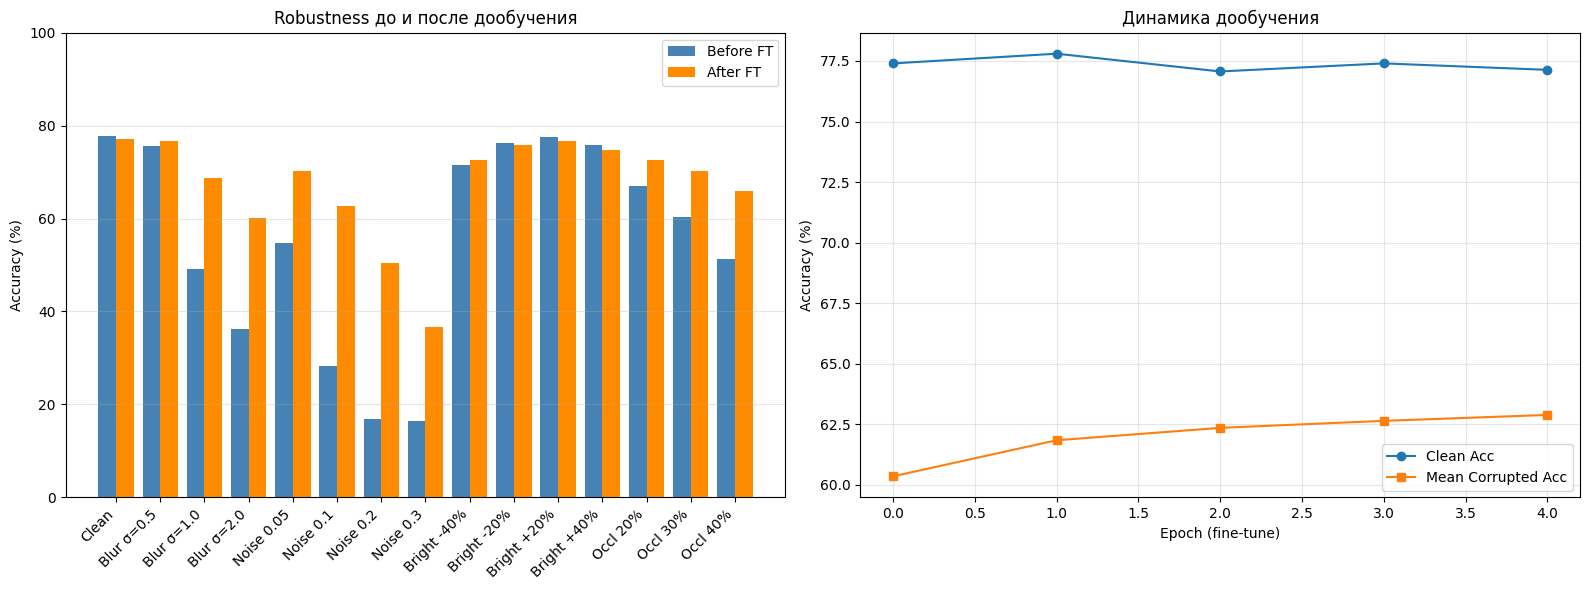

In [13]:

print("=" * 60)
print("ПОЛНАЯ ОЦЕНКА ПОСЛЕ ДООБУЧЕНИЯ")
print("=" * 60)

finetuned_results = {}
finetuned_results['Clean'] = evaluate_loader(model, test_loader)
for sigma in [0.5, 1.0, 2.0]:
    finetuned_results[f'Blur σ={sigma}'] = evaluate_corrupted(model, 'blur', sigma)
for sev in [0.05, 0.10, 0.20, 0.30]:
    finetuned_results[f'Noise {sev}'] = evaluate_corrupted(model, 'noise', sev)
for sev in [-0.40, -0.20, 0.20, 0.40]:
    finetuned_results[f'Bright {sev:+.0%}'] = evaluate_corrupted(model, 'brightness', sev)
for sev in [0.20, 0.30, 0.40]:
    finetuned_results[f'Occl {sev:.0%}'] = evaluate_corrupted(model, 'occlusion', sev)

print(f"\n{'Corruption':20s} | {'Before':>8s} | {'After':>8s} | {'Δ':>9s}")
print("-" * 55)
for k in baseline_results:
    b, a = baseline_results[k], finetuned_results[k]
    d = a - b
    print(f"{k:20s} | {b:7.2f}% | {a:7.2f}% | {'+' if d>=0 else ''}{d:7.2f}%")
print("-" * 55)

mean_after      = np.mean(list(finetuned_results.values()))
mean_after_corr = np.mean([v for k, v in finetuned_results.items() if k != 'Clean'])
print(f"{'MEAN (all)':20s} | {mean_before:7.2f}% | {mean_after:7.2f}% | "
      f"{'+' if mean_after-mean_before>=0 else ''}{mean_after-mean_before:7.2f}%")
print(f"{'MEAN (corrupted)':20s} | {mean_before_corr:7.2f}% | {mean_after_corr:7.2f}% | "
      f"{'+' if mean_after_corr-mean_before_corr>=0 else ''}{mean_after_corr-mean_before_corr:7.2f}%")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(baseline_results)); w = 0.4
axes[0].bar(x - w/2, baseline_results.values(), w, label='Before FT', color='steelblue')
axes[0].bar(x + w/2, finetuned_results.values(), w, label='After FT', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(baseline_results.keys(), rotation=45, ha='right')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 100)
axes[0].set_title('Robustness до и после дообучения')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(history_ft['clean_acc'], label='Clean Acc', marker='o')
axes[1].plot(history_ft['mean_corr'], label='Mean Corrupted Acc', marker='s')
axes[1].set_xlabel('Epoch (fine-tune)'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Динамика дообучения')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

    airplane     0.7883    0.8190    0.8033      1000
  automobile     0.8483    0.9450    0.8940      1000
        bird     0.7428    0.5920    0.6589      1000
         cat     0.6676    0.4900    0.5652      1000
        deer     0.7600    0.7190    0.7390      1000
         dog     0.6728    0.6970    0.6847      1000
        frog     0.7023    0.8990    0.7886      1000
       horse     0.7770    0.8430    0.8086      1000
        ship     0.8763    0.8640    0.8701      1000
       truck     0.8678    0.8530    0.8603      1000

    accuracy                         0.7721     10000
   macro avg     0.7703    0.7721    0.7673     10000
weighted avg     0.7703    0.7721    0.7673     10000



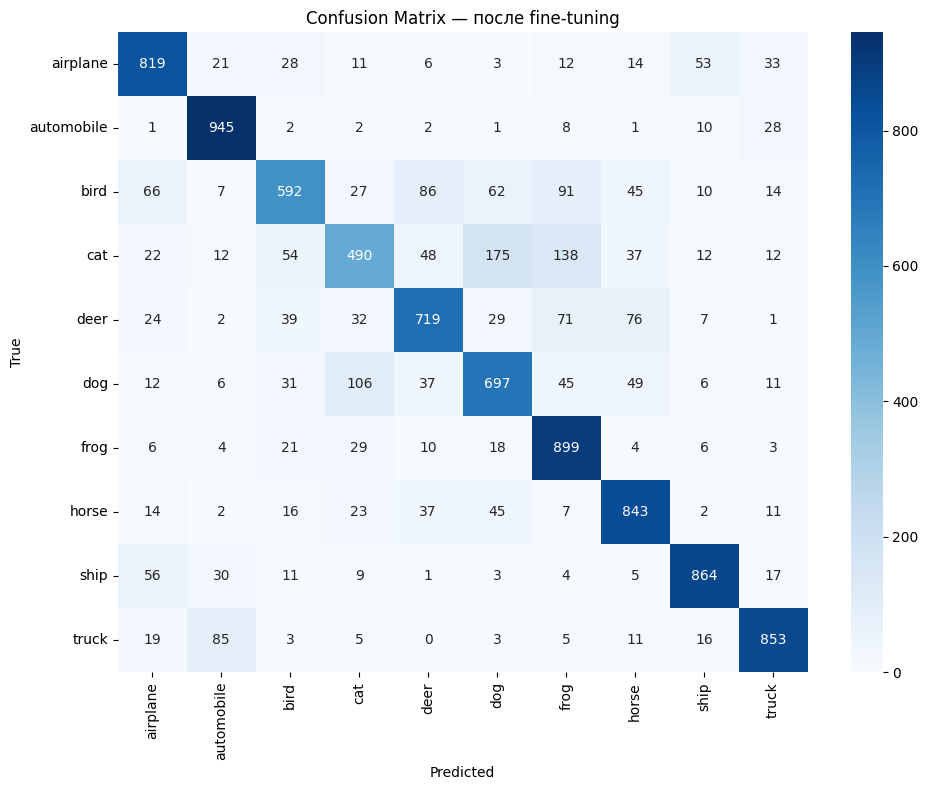

In [14]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        out = model(images)
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
                            target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — после fine-tuning')
plt.tight_layout(); plt.show()